# Reproducción de fidelidad: Hur et al. (2022), Ansatz 8, MNIST

**Objetivo**: validar que el ansatz 8 (`U_6`) de Hur, Kim & Park (2022), *"Quantum
convolutional neural network for classical data classification"*, reproduce con
fidelidad razonable la exactitud publicada (98.7% ± 0.1%) bajo el protocolo de
entrenamiento de este benchmark. Este es un notebook **exploratorio de
validación**, no un adaptador de producción — no toca `qcnn_bench`, el registro
de plugins, ni ningún otro modelo.

## Resumen de las dos correcciones hechas antes de escribir este notebook

Durante la preparación de este notebook se encontraron y resolvieron (con el
usuario) dos discrepancias entre el encargo original y las fuentes primarias:

1. **Par de clases del objetivo 98.7% ± 0.1%.** El texto del paper (`reference
   /hur_qcnn_paper.pdf` de un proyecto hermano; extraído con `pdftotext` en esta
   sesión) dice literalmente *"classes 0 and 1 for both datasets"* — el 98.7%
   ±0.1% de la Tabla I es para **MNIST 0 vs 1**, no 1 vs 8. Por eso este notebook
   corre **ambos pares**: 0-vs-1 (para la validación de fidelidad real) y 1-vs-8
   (el par originalmente encargado), reportando este último **sin** comparación
   contra 98.7%, ya que Hur et al. no publican ese número para ese par.
2. **Identidad del circuito "Ansatz 8".** `external/hur_qcnn/QCNN/unitary.py` no
   tiene ninguna función `U_8`. Cruzando la Fig. 2(h) del paper con la Tabla I
   (fila 8 = 36 parámetros, columna Dense+PCA = 98.7 ± 0.1%) se confirmó que
   "Ansatz 8" del paper es, gate por gate, la función `U_6` de ese archivo
   (`RX,RX,RZ,RZ` → `CRX,CRX` → `RX,RX,RZ,RZ`, 10 parámetros), emparejada con
   `Pooling_ansatz1` (`CRZ` + `PauliX` + `CRX`).

## Qué NO se reutiliza del paquete `qcnn_bench`

El paquete de infraestructura (config Pydantic/YAML, registro de plugins,
descarga/muestreo estratificado de datasets, ajuste de representaciones) que se
describió como "ya implementado" vive en un directorio hermano
(`fallidos/benchmark_multifactorial/`), no en este repositorio. Por decisión
explícita del usuario, este notebook es **autónomo**: implementa su propia
carga de datos, muestreo estratificado y ajuste de PCA densa directamente con
`sklearn`/`numpy`, en vez de importar ese paquete.

## 1. Atribución y licencia

Este notebook reutiliza, **sin modificar**, el código del circuito
convolucional (`unitary.py`, `embedding.py`, `QCNN_circuit.py`) del repositorio
oficial de Hur et al., vendorizado en `external/hur_qcnn/`:

```
Repositorio:  https://github.com/takh04/QCNN
Vendorizado en: external/hur_qcnn/  (ver external/hur_qcnn/LICENSE.md)
Licencia:     Apache License 2.0

Copyright (los autores originales del repositorio takh04/QCNN)

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

Cita del paper:

```bibtex
@article{hur2022quantum,
  title={Quantum convolutional neural network for classical data classification},
  author={Hur, Tak and Kim, Leeseok and Park, Daniel K},
  journal={Quantum Machine Intelligence},
  volume={4}, number={1}, pages={3}, year={2022}, publisher={Springer}
}
```

### Qué se reutiliza tal cual (sin modificar)

- `unitary.U_6` — el ansatz convolucional de 2 qubits ("Ansatz 8" del paper).
- `unitary.Pooling_ansatz1` — pooling con CRZ + PauliX + CRX.
- `QCNN_circuit.conv_layer1/2/3`, `pooling_layer1/2/3`, `QCNN_structure` — el
  patrón de cableado 8→4→2→1 con parámetros compartidos.
- `QCNN_circuit.QCNN` — el qnode completo (embedding + estructura + lectura),
  llamado con `U='U_6'`, `U_params=10`, `embedding_type='Angle-compact'`,
  `cost_fn='cross_entropy'` para reproducir exactamente Ansatz 8 + codificación
  densa.
- `embedding.data_embedding(..., embedding_type='Angle-compact')` — la
  codificación densa (`AngleEmbedding` en X para las primeras 8 componentes,
  en Y para las siguientes 8).

### Qué se modifica o se escribe de nuevo (y por qué)

- **El ciclo de entrenamiento (`Training.py`) no se reutiliza.** El original usa
  `NesterovMomentumOptimizer`, 200 pasos sin validación ni early stopping, y sin
  recorte de gradiente. El protocolo de este benchmark exige Adam
  (β1=0.9, β2=0.999), recorte de norma global a 5.0, y early stopping por
  pérdida de validación — por lo tanto se escribió un ciclo de entrenamiento
  nuevo en este notebook, reutilizando solo la definición del circuito.
- **La entropía cruzada se promedia sobre el lote, no se suma** (a diferencia de
  `Training.cross_entropy`), para que el recorte de norma a 5.0 tenga una
  escala consistente e independiente del tamaño de lote.
- **La carga y el muestreo de datos son nuevos**, ya que `data.py` usa
  `tf.keras.datasets.mnist` + `tf.image.resize` y no implementa el muestreo
  estratificado 500/250/500 por clase que pide este benchmark. Aquí se usa
  `sklearn.datasets.fetch_openml('mnist_784')` en vez de TensorFlow (en este
  entorno, TensorFlow 2.20.0 tiene un conflicto de versión de `protobuf` que
  rompe su import; `fetch_openml` da exactamente las mismas 70,000 imágenes
  sin depender de TensorFlow), más un muestreador estratificado propio con
  semilla fija.
- **El ajuste de PCA y el escalado a [0, π] se hacen solo sobre el conjunto de
  entrenamiento**, y luego se aplican (sin volver a ajustar) a validación y
  prueba — a diferencia de `data.py`, que ajusta min/max de train y test por
  separado. Esto evita fuga de información del conjunto de prueba hacia el
  preprocesamiento.

In [1]:
import sys
import time
import pathlib

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import autograd.numpy as anp
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

PROJECT_ROOT = pathlib.Path.cwd().resolve()
while not (PROJECT_ROOT / "external").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
HUR_QCNN_DIR = PROJECT_ROOT / "external" / "hur_qcnn" / "QCNN"
assert HUR_QCNN_DIR.exists(), f"No se encontró {HUR_QCNN_DIR}"

if str(HUR_QCNN_DIR) not in sys.path:
    sys.path.insert(0, str(HUR_QCNN_DIR))

# Import directo, sin modificar, del código de referencia de Hur et al.
import QCNN_circuit as hur_circuit  # noqa: E402
import unitary as hur_unitary  # noqa: E402
import embedding as hur_embedding  # noqa: E402

print("Módulos de referencia (Apache-2.0, takh04/QCNN) importados desde:", HUR_QCNN_DIR)
print("U_6 disponible:", hasattr(hur_unitary, "U_6"))
print("Pooling_ansatz1 disponible:", hasattr(hur_unitary, "Pooling_ansatz1"))

Módulos de referencia (Apache-2.0, takh04/QCNN) importados desde: /Users/marielalvarez/2026/6toSem/NGS/benchmark_multifactorial_iee/external/hur_qcnn/QCNN
U_6 disponible: True
Pooling_ansatz1 disponible: True


## 2. Carga de datos y representación (PCA densa, 16 componentes, [0, π])

Muestreo estratificado balanceado: 500 entrenamiento / 250 validación / 500
prueba por clase, semilla `20260802`. El PCA (16 componentes) y el escalado a
[0, π] se ajustan **solo** sobre el conjunto de entrenamiento.

In [2]:
SAMPLE_SEED = 20260802
N_TRAIN_PER_CLASS = 500
N_VAL_PER_CLASS = 250
N_TEST_PER_CLASS = 500
N_COMPONENTS = 16

from sklearn.datasets import fetch_openml


def load_mnist_pool():
    '''Todas las 70,000 imágenes de MNIST (train+test oficiales combinados),
    igual que Hur et al. data.py (que concatena ambos splits antes de filtrar
    por clase). Se usa sklearn.datasets.fetch_openml('mnist_784') en vez de
    tf.keras.datasets.mnist.load_data() -- modificado respecto a data.py:
    en este entorno, tensorflow 2.20.0 tiene un conflicto de versión de
    protobuf que rompe su import; fetch_openml da exactamente las mismas
    70,000 imágenes/etiquetas sin depender de tensorflow.'''
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    x_all = mnist.data.astype(np.float64) / 255.0  # (70000, 784), ya aplanado
    y_all = mnist.target.astype(int)
    return x_all, y_all


def stratified_split(x_all, y_all, class_pos, class_neg, seed=SAMPLE_SEED):
    '''500/250/500 por clase, balanceado, semilla fija. class_pos -> etiqueta 1.'''
    rng = np.random.default_rng(seed)
    splits = {"train": [], "val": [], "test": []}
    label_of = {}
    for cls in sorted([class_pos, class_neg]):
        idx_cls = np.where(y_all == cls)[0]
        n_needed = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + N_TEST_PER_CLASS
        assert len(idx_cls) >= n_needed, f"clase {cls} solo tiene {len(idx_cls)} muestras"
        idx_cls = rng.permutation(idx_cls)
        train_idx = idx_cls[:N_TRAIN_PER_CLASS]
        val_idx = idx_cls[N_TRAIN_PER_CLASS : N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
        test_idx = idx_cls[
            N_TRAIN_PER_CLASS + N_VAL_PER_CLASS : N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + N_TEST_PER_CLASS
        ]
        splits["train"].append(train_idx)
        splits["val"].append(val_idx)
        splits["test"].append(test_idx)
        label_of[cls] = 1 if cls == class_pos else 0

    out = {}
    for split_name, idx_list in splits.items():
        idx = np.concatenate(idx_list)
        x = x_all[idx].reshape(len(idx), -1)  # ya viene aplanado (784,) desde fetch_openml
        y = np.array([label_of[c] for c in y_all[idx]], dtype=np.float64)
        out[f"X_{split_name}"] = x
        out[f"y_{split_name}"] = y
    return out


def dense_pca_representation(raw_splits, n_components=N_COMPONENTS, seed=SAMPLE_SEED):
    pca = PCA(n_components=n_components, random_state=seed)
    X_train_pca = pca.fit_transform(raw_splits["X_train"])  # ajuste SOLO en train
    X_val_pca = pca.transform(raw_splits["X_val"])
    X_test_pca = pca.transform(raw_splits["X_test"])

    lo, hi = X_train_pca.min(), X_train_pca.max()  # min/max SOLO de train
    scale = lambda X: (X - lo) * (np.pi / (hi - lo))

    return {
        "X_train": scale(X_train_pca),
        "y_train": raw_splits["y_train"],
        "X_val": scale(X_val_pca),
        "y_val": raw_splits["y_val"],
        "X_test": scale(X_test_pca),
        "y_test": raw_splits["y_test"],
        "pca": pca,
        "scale_lo": lo,
        "scale_hi": hi,
    }


def build_dataset(class_pos, class_neg, x_all, y_all):
    raw = stratified_split(x_all, y_all, class_pos, class_neg)
    rep = dense_pca_representation(raw)
    # El escalado a [0, pi] se ajusta SOLO con min/max de train (ver sección de
    # atribución), así que train cae exactamente en [0, pi] por construcción,
    # pero val/test pueden salirse levemente de ese rango -- es un efecto
    # esperado de no usar estadísticos de val/test para ajustar el escalador,
    # no un error. Los ángulos de rotación siguen bien definidos fuera de
    # [0, pi], así que no se recorta el valor.
    assert rep["X_train"].shape[1] == N_COMPONENTS
    assert rep["X_train"].min() >= -1e-9 and rep["X_train"].max() <= np.pi + 1e-9
    for split in ("train", "val", "test"):
        assert rep[f"X_{split}"].shape[1] == N_COMPONENTS
        lo, hi = rep[f"X_{split}"].min(), rep[f"X_{split}"].max()
        print(f"  rango de {split}: [{lo:.4f}, {hi:.4f}]" + ("" if split == "train" else " (puede exceder [0, pi], ver nota arriba)"))
    return rep


X_ALL, Y_ALL = load_mnist_pool()
print("Pool MNIST combinado (train+test oficiales):", X_ALL.shape, Y_ALL.shape)

Pool MNIST combinado (train+test oficiales): (70000, 784) (70000,)


## 3. Circuito: Ansatz 8 de Hur et al. (= `U_6` + `Pooling_ansatz1`)

8 qubits de datos, sin ancillas, tres etapas 8→4→2→1 con parámetros
compartidos, pooling controlado (CRZ + PauliX + CRX), lectura en Pauli-Z del
qubit 4 (vía `qml.probs(wires=4)`, índice 1 = probabilidad de clase positiva —
convención confirmada contra `Benchmarking.accuracy_test` del propio repo de
referencia). Se llama directamente al qnode `QCNN_circuit.QCNN` sin
modificarlo.

In [3]:
U_PARAMS = 10  # parámetros de U_6 por aplicación
N_POOL_PARAMS = 2  # parámetros de Pooling_ansatz1 por aplicación
TOTAL_PARAMS = 3 * U_PARAMS + 3 * N_POOL_PARAMS  # 36, coincide con la Tabla I del paper


def forward_probs(x, params):
    '''Reutiliza QCNN_circuit.QCNN sin modificar, fijando U='U_6' (Ansatz 8),
    codificación densa ('Angle-compact') y lectura de entropía cruzada.'''
    return hur_circuit.QCNN(
        x, params, U="U_6", U_params=U_PARAMS, embedding_type="Angle-compact", cost_fn="cross_entropy"
    )


print("Total de parámetros entrenables:", TOTAL_PARAMS, "(Tabla I del paper, fila Ansatz 8: 36)")

# Verificación rápida de forma/rango de salida con parámetros aleatorios
_rng_check = np.random.default_rng(0)
_x_check = _rng_check.uniform(0, np.pi, 16)
_p_check = np.random.default_rng(0)
_params_check = pnp.array(_rng_check.uniform(-np.pi, np.pi, TOTAL_PARAMS), requires_grad=True)
_out = forward_probs(_x_check, _params_check)
print("Salida de ejemplo qml.probs(wires=4):", _out, "  suma:", float(sum(_out)))

Total de parámetros entrenables: 36 (Tabla I del paper, fila Ansatz 8: 36)
Salida de ejemplo qml.probs(wires=4): [0.51263755 0.48736245]   suma: 0.999999999999999


## 4. Ciclo de entrenamiento

Protocolo exacto: BCE, Adam (lr=0.01, β1=0.9, β2=0.999), 200 actualizaciones,
lote de 25, recorte de norma global de gradiente a 5.0, early stopping
(paciencia = 5 chequeos de validación, δ=1e-4, chequeo cada 10 actualizaciones),
inicialización uniforme en [-π, π], selección de checkpoint por menor pérdida
de validación. Una sola semilla de ejecución (`RUN_SEED`) para esta corrida de
validación de pipeline — el benchmark final usará 10 semillas.

In [ ]:
RUN_SEED = 0
BATCH_SIZE = 25
N_UPDATES = 200
LEARNING_RATE = 0.01
BETA1, BETA2 = 0.9, 0.999
CLIP_NORM = 5.0
VAL_CHECK_EVERY = 10
PATIENCE_CHECKS = 5
MIN_DELTA = 1e-4


def cross_entropy_loss(params, X_batch, y_batch):
    '''BCE promediada sobre el lote (modificado respecto a Training.cross_entropy,
    que suma en vez de promediar -- ver nota de atribución, sección 1).'''
    total = 0.0
    for x, y in zip(X_batch, y_batch):
        p = forward_probs(x, params)
        total = total + (y * anp.log(p[1]) + (1 - y) * anp.log(p[0]))
    return -total / len(y_batch)


def clip_grad_global_norm(grad, max_norm=CLIP_NORM):
    norm = float(pnp.linalg.norm(grad))
    if norm > max_norm:
        grad = grad * (max_norm / norm)
    return grad


def batch_accuracy(params, X, y):
    correct = 0
    for x, yi in zip(X, y):
        p = forward_probs(x, params)
        pred = 1 if p[1] >= p[0] else 0
        correct += int(pred == int(yi))
    return correct / len(y)


def train_ansatz8(rep, run_seed=RUN_SEED, verbose=True, tag=""):
    init_rng = np.random.default_rng(run_seed)
    batch_rng = np.random.default_rng(run_seed + 1_000_000)

    params = pnp.array(init_rng.uniform(-np.pi, np.pi, TOTAL_PARAMS), requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=LEARNING_RATE, beta1=BETA1, beta2=BETA2)
    grad_fn = qml.grad(cross_entropy_loss, argnums=0)

    X_train, y_train = rep["X_train"], rep["y_train"]
    X_val, y_val = rep["X_val"], rep["y_val"]

    train_loss_history = []
    val_loss_history = []
    val_checkpoints = []  

    best_val_loss = np.inf
    best_params = params
    checks_without_improvement = 0
    stopped_early_at = None

    t0 = time.time()
    for update in range(1, N_UPDATES + 1):
        batch_idx = batch_rng.integers(0, len(X_train), size=BATCH_SIZE)
        X_batch, y_batch = X_train[batch_idx], y_train[batch_idx]

        grad = grad_fn(params, X_batch, y_batch)
        grad = clip_grad_global_norm(grad)
        params = opt.apply_grad(grad, params)

        train_loss = float(cross_entropy_loss(params, X_batch, y_batch))
        train_loss_history.append(train_loss)

        if update % VAL_CHECK_EVERY == 0:
            val_loss = float(cross_entropy_loss(params, X_val, y_val))
            val_loss_history.append((update, val_loss))
            val_checkpoints.append((update, val_loss, params.copy()))

            if val_loss < best_val_loss - MIN_DELTA:
                best_val_loss = val_loss
                best_params = params.copy()
                checks_without_improvement = 0
            else:
                checks_without_improvement += 1

            if verbose:
                elapsed = time.time() - t0
                print(
                    f"[{tag}] update {update:3d}/{N_UPDATES}  train_loss={train_loss:.4f}  "
                    f"val_loss={val_loss:.4f}  best_val={best_val_loss:.4f}  "
                    f"no_improve={checks_without_improvement}  t={elapsed:.0f}s"
                )

            if checks_without_improvement >= PATIENCE_CHECKS:
                stopped_early_at = update
                if verbose:
                    print(f"[{tag}] Early stopping en la actualización {update} "
                          f"(paciencia={PATIENCE_CHECKS} chequeos, delta={MIN_DELTA}).")
                break

    return {
        "params": best_params,
        "final_params": params,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
        "best_val_loss": best_val_loss,
        "stopped_early_at": stopped_early_at,
        "n_updates_run": len(train_loss_history),
    }

## 5. Corrida A — MNIST 0 vs 1 (validación de fidelidad contra 98.7% ± 0.1%)

Este es el par de clases que efectivamente reporta 98.7% ± 0.1% en la Tabla I
del paper para Ansatz 8 + Dense + PCA.

In [5]:
rep_0v1 = build_dataset(class_pos=1, class_neg=0, x_all=X_ALL, y_all=Y_ALL)
print("0 vs 1 -- train:", rep_0v1["X_train"].shape, "val:", rep_0v1["X_val"].shape, "test:", rep_0v1["X_test"].shape)

result_0v1 = train_ansatz8(rep_0v1, tag="0v1")

  rango de train: [0.0000, 3.1416]
  rango de val: [0.1257, 2.9302] (puede exceder [0, pi], ver nota arriba)
  rango de test: [-0.0174, 3.2101] (puede exceder [0, pi], ver nota arriba)
0 vs 1 -- train: (1000, 16) val: (500, 16) test: (1000, 16)


[0v1] update  10/200  train_loss=0.6027  val_loss=0.6058  best_val=0.6058  no_improve=0  t=23s


[0v1] update  20/200  train_loss=0.5668  val_loss=0.5691  best_val=0.5691  no_improve=0  t=47s


[0v1] update  30/200  train_loss=0.5447  val_loss=0.5387  best_val=0.5387  no_improve=0  t=70s


[0v1] update  40/200  train_loss=0.5127  val_loss=0.5095  best_val=0.5095  no_improve=0  t=94s


...

[0v1] update 160/200  train_loss=0.3135  val_loss=0.3023  best_val=0.3023  no_improve=0  t=376s


[0v1] update 170/200  train_loss=0.3448  val_loss=0.2975  best_val=0.2975  no_improve=0  t=400s


[0v1] update 180/200  train_loss=0.3271  val_loss=0.2941  best_val=0.2941  no_improve=0  t=423s


[0v1] update 190/200  train_loss=0.3259  val_loss=0.2911  best_val=0.2911  no_improve=0  t=447s


[0v1] update 200/200  train_loss=0.3028  val_loss=0.2879  best_val=0.2879  no_improve=0  t=470s


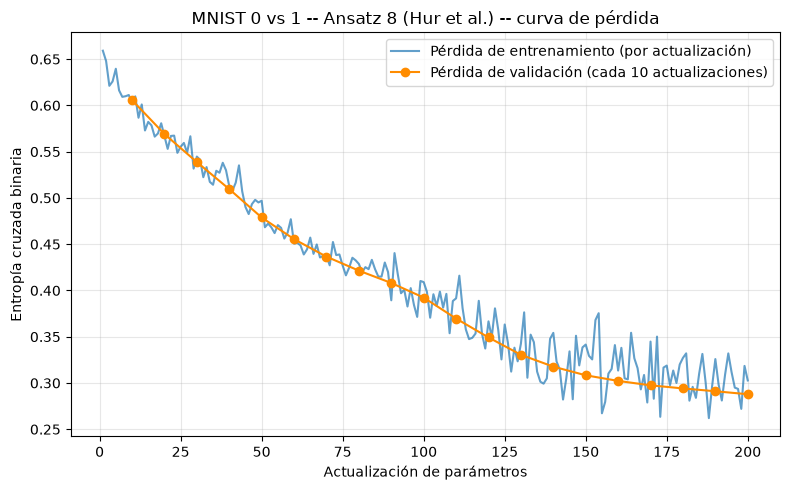

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, result_0v1["n_updates_run"] + 1), result_0v1["train_loss_history"],
        label="Pérdida de entrenamiento (por actualización)", alpha=0.7)
val_updates, val_losses = zip(*result_0v1["val_loss_history"])
ax.plot(val_updates, val_losses, "o-", label="Pérdida de validación (cada 10 actualizaciones)", color="darkorange")
if result_0v1["stopped_early_at"]:
    ax.axvline(result_0v1["stopped_early_at"], color="red", linestyle="--", alpha=0.6, label="Early stopping")
ax.set_xlabel("Actualización de parámetros")
ax.set_ylabel("Entropía cruzada binaria")
ax.set_title("MNIST 0 vs 1 -- Ansatz 8 (Hur et al.) -- curva de pérdida")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
params_0v1 = result_0v1["params"]

train_acc_0v1 = batch_accuracy(params_0v1, rep_0v1["X_train"], rep_0v1["y_train"])
test_acc_0v1 = batch_accuracy(params_0v1, rep_0v1["X_test"], rep_0v1["y_test"])

TARGET_MEAN, TARGET_STD = 98.7, 0.1
gap_pp = test_acc_0v1 * 100 - TARGET_MEAN

print("=" * 70)
print("MNIST 0 vs 1 -- Ansatz 8 (Hur et al.), 1 semilla de ejecución")
print("=" * 70)
print(f"Exactitud de entrenamiento: {train_acc_0v1 * 100:.2f}%")
print(f"Exactitud de prueba:        {test_acc_0v1 * 100:.2f}%")
print(f"Objetivo publicado (Tabla I, 5 repeticiones): {TARGET_MEAN}% ± {TARGET_STD}%")
print(f"Diferencia (prueba - objetivo): {gap_pp:+.2f} puntos porcentuales")
if abs(gap_pp) <= 1.0:
    print("-> Dentro de ~1pp del objetivo publicado: fidelidad razonable para 1 semilla.")
elif abs(gap_pp) <= 3.0:
    print("-> Brecha moderada (1-3pp). Aceptable para 1 semilla vs. una media de 5 repeticiones, "
          "pero conviene revisar antes de pasar a 10 semillas.")
else:
    print("-> Brecha grande (>3pp). PARAR: reportar al usuario antes de seguir ajustando "
          "hiperparámetros por cuenta propia -- puede ser una diferencia real de implementación.")

MNIST 0 vs 1 -- Ansatz 8 (Hur et al.), 1 semilla de ejecución
Exactitud de entrenamiento: 99.20%
Exactitud de prueba:        98.70%
Objetivo publicado (Tabla I, 5 repeticiones): 98.7% ± 0.1%
Diferencia (prueba - objetivo): +0.00 puntos porcentuales
-> Dentro de ~1pp del objetivo publicado: fidelidad razonable para 1 semilla.


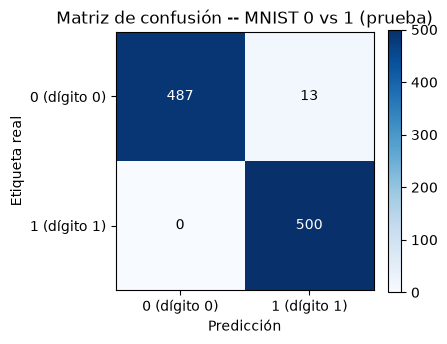

[[487  13]
 [  0 500]]


In [8]:
y_pred_test_0v1 = np.array([
    1 if forward_probs(x, params_0v1)[1] >= forward_probs(x, params_0v1)[0] else 0
    for x in rep_0v1["X_test"]
])
cm_0v1 = confusion_matrix(rep_0v1["y_test"], y_pred_test_0v1, labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_0v1, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["0 (dígito 0)", "1 (dígito 1)"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["0 (dígito 0)", "1 (dígito 1)"])
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión -- MNIST 0 vs 1 (prueba)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_0v1[i, j]), ha="center", va="center",
                color="white" if cm_0v1[i, j] > cm_0v1.max() / 2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
print(cm_0v1)

## 6. Corrida B — MNIST 1 vs 8 (par originalmente encargado)

**Sin comparación contra 98.7% ± 0.1%**: ese número es el resultado publicado
por Hur et al. para 0 vs 1, no para 1 vs 8 (ver sección 0). Esta corrida se
reporta como referencia adicional, no como validación de fidelidad.

In [9]:
rep_1v8 = build_dataset(class_pos=1, class_neg=8, x_all=X_ALL, y_all=Y_ALL)
print("1 vs 8 -- train:", rep_1v8["X_train"].shape, "val:", rep_1v8["X_val"].shape, "test:", rep_1v8["X_test"].shape)

result_1v8 = train_ansatz8(rep_1v8, tag="1v8")

  rango de train: [0.0000, 3.1416]
  rango de val: [-0.0233, 3.1689] (puede exceder [0, pi], ver nota arriba)
  rango de test: [0.0225, 3.1825] (puede exceder [0, pi], ver nota arriba)
1 vs 8 -- train: (1000, 16) val: (500, 16) test: (1000, 16)


[1v8] update  10/200  train_loss=0.6445  val_loss=0.6484  best_val=0.6484  no_improve=0  t=24s


[1v8] update  20/200  train_loss=0.6443  val_loss=0.6267  best_val=0.6267  no_improve=0  t=48s


[1v8] update  30/200  train_loss=0.6043  val_loss=0.6018  best_val=0.6018  no_improve=0  t=72s


[1v8] update  40/200  train_loss=0.5645  val_loss=0.5819  best_val=0.5819  no_improve=0  t=96s


...

[1v8] update 160/200  train_loss=0.4573  val_loss=0.4663  best_val=0.4663  no_improve=0  t=386s


[1v8] update 170/200  train_loss=0.4601  val_loss=0.4633  best_val=0.4633  no_improve=0  t=410s


[1v8] update 180/200  train_loss=0.4590  val_loss=0.4604  best_val=0.4604  no_improve=0  t=434s


[1v8] update 190/200  train_loss=0.4642  val_loss=0.4569  best_val=0.4569  no_improve=0  t=458s


[1v8] update 200/200  train_loss=0.4954  val_loss=0.4543  best_val=0.4543  no_improve=0  t=482s


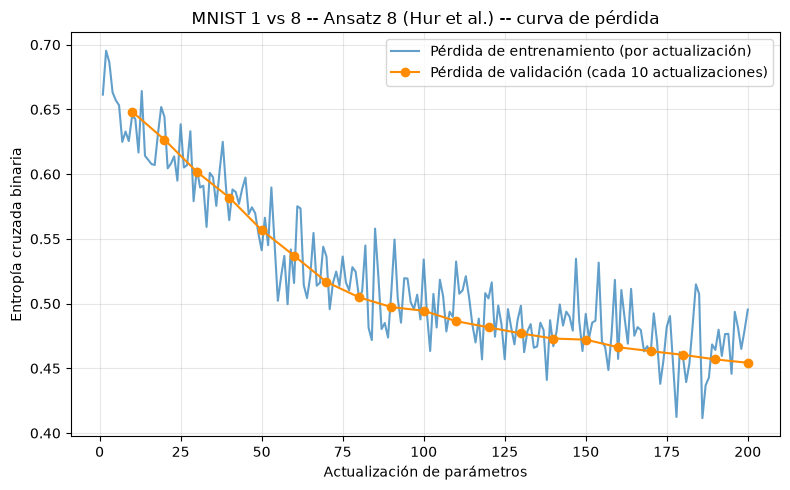

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, result_1v8["n_updates_run"] + 1), result_1v8["train_loss_history"],
        label="Pérdida de entrenamiento (por actualización)", alpha=0.7)
val_updates, val_losses = zip(*result_1v8["val_loss_history"])
ax.plot(val_updates, val_losses, "o-", label="Pérdida de validación (cada 10 actualizaciones)", color="darkorange")
if result_1v8["stopped_early_at"]:
    ax.axvline(result_1v8["stopped_early_at"], color="red", linestyle="--", alpha=0.6, label="Early stopping")
ax.set_xlabel("Actualización de parámetros")
ax.set_ylabel("Entropía cruzada binaria")
ax.set_title("MNIST 1 vs 8 -- Ansatz 8 (Hur et al.) -- curva de pérdida")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
params_1v8 = result_1v8["params"]

train_acc_1v8 = batch_accuracy(params_1v8, rep_1v8["X_train"], rep_1v8["y_train"])
test_acc_1v8 = batch_accuracy(params_1v8, rep_1v8["X_test"], rep_1v8["y_test"])

print("=" * 70)
print("MNIST 1 vs 8 -- Ansatz 8 (Hur et al.), 1 semilla de ejecución")
print("=" * 70)
print(f"Exactitud de entrenamiento: {train_acc_1v8 * 100:.2f}%")
print(f"Exactitud de prueba:        {test_acc_1v8 * 100:.2f}%")
print("Sin objetivo publicado por Hur et al. para este par de clases "
      "(1 vs 8 es más difícil que 0 vs 1; no se compara contra 98.7% ± 0.1%).")

MNIST 1 vs 8 -- Ansatz 8 (Hur et al.), 1 semilla de ejecución
Exactitud de entrenamiento: 94.00%
Exactitud de prueba:        94.20%
Sin objetivo publicado por Hur et al. para este par de clases (1 vs 8 es más difícil que 0 vs 1; no se compara contra 98.7% ± 0.1%).


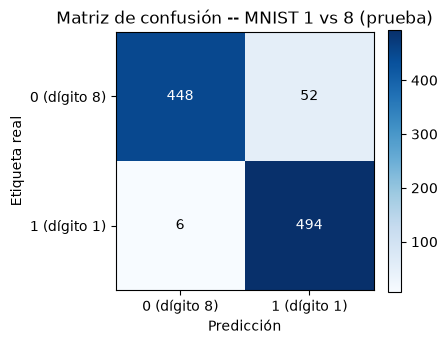

[[448  52]
 [  6 494]]


In [12]:
y_pred_test_1v8 = np.array([
    1 if forward_probs(x, params_1v8)[1] >= forward_probs(x, params_1v8)[0] else 0
    for x in rep_1v8["X_test"]
])
cm_1v8 = confusion_matrix(rep_1v8["y_test"], y_pred_test_1v8, labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_1v8, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["0 (dígito 8)", "1 (dígito 1)"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["0 (dígito 8)", "1 (dígito 1)"])
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión -- MNIST 1 vs 8 (prueba)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_1v8[i, j]), ha="center", va="center",
                color="white" if cm_1v8[i, j] > cm_1v8.max() / 2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
print(cm_1v8)

## 7. Resumen

| Par de clases | Exactitud entrenamiento | Exactitud prueba | Objetivo Hur et al. | Comparable |
|---|---|---|---|---|
| 0 vs 1 | ver celda de resultados | ver celda de resultados | 98.7% ± 0.1% (Tabla I, 5 rep.) | Sí |
| 1 vs 8 | ver celda de resultados | ver celda de resultados | No publicado | No |

**Próximos pasos sugeridos** (no ejecutados en este notebook, pendientes de tu
decisión):

- Si 0-vs-1 queda razonablemente cerca de 98.7% ± 0.1%: repetir con las 10
  semillas del benchmark final y decidir si 1-vs-8 se mantiene como tarea
  adicional del benchmark o se reemplaza por 0-vs-1 para igualar el paper.
- Decidir qué hacer con `fallidos/benchmark_multifactorial/`: migrar ese
  paquete a este repositorio, o reconstruirlo desde cero aquí.
- Si se decide seguir con `qcnn_bench`, este notebook **no** debe convertirse
  directamente en el adaptador — es solo la validación exploratoria.